# Prática 1 · Visão Computacional — Pipeline de Pré-processamento com Filtros Lineares

**Integrantes da equipe:** Ivan Edward, Elizabete Barbosa, Davi Melo

**Dataset:** 100 imagens de placas veiculares (convenção de nomes CCPD) em `images/`.

**Política respeitada:** todas as operações aplicadas às imagens são **filtros lineares** (convoluções e a transformação de intensidade afim $T(r)=a\,r+b$). Nenhuma imagem foi editada ou filtrada por IA generativa; as 100 imagens do `.zip` são geradas **por este notebook**, pelas funções de `preprocessing_pipeline.py`, e a linearidade de cada bloco é verificada numericamente na seção 1.7.

## Roteiro

| Parte | Conteúdo | Seções |
|---|---|---|
| **1 — Análise Inicial** | metadados CCPD, métricas objetivas de qualidade, categorização por problema dominante, inventário do que é (e do que não é) linear, comparação de candidatos por contexto | 1.1 – 1.9 |
| **2 — Implementação** | diagrama de blocos, métrica de avaliação (definida *antes* de calibrar), calibração por busca em grade, execução sobre as 100 imagens | 2.1 – 2.6 |
| **3 — Análise dos Resultados** | resultados agregados, antes/depois, onde e por que falha, resposta à pergunta "um pipeline serve a todas?" | 3.1 – 3.4 |
| **Entregáveis** | geração dos `.zip` com as 100 imagens filtradas | 4 |

A pergunta central da prática (slide 8): *projete um pipeline só de filtros lineares e descubra se ele generaliza para as 100 imagens*. Construímos dois pipelines com **exatamente os mesmos blocos lineares**:

* **Pipeline A — global:** parâmetros fixos, idênticos para as 100 imagens, sem usar nenhuma anotação da placa.
* **Pipeline B — adaptativo:** mesmos blocos; a normalização lê estatísticas do recorte da placa e o unsharp mask só liga quando o diagnóstico da imagem indica desfoque.

In [1]:
import sys
import sqlite3
import zipfile
import itertools
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import skimage

sys.path.insert(0, str(Path.cwd()))
import preprocessing_pipeline as pp

IMAGES_DIR = Path("images")
OUT_GLOBAL = Path("images_processed_global")     # saida do pipeline A
OUT_ADAPTIVE = Path("images_processed")          # saida do pipeline B (entregavel principal)
np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

print("python", sys.version.split()[0], "| opencv", cv2.__version__, "| numpy", np.__version__,
      "| pandas", pd.__version__, "| scikit-image", skimage.__version__)

python 3.13.14 | opencv 5.0.0 | numpy 2.5.2 | pandas 3.0.5 | scikit-image 0.26.0


# Parte 1 — Análise Inicial

## 1.1 Metadados embutidos no nome do arquivo (padrão CCPD)

Formato: `area-tilt_h_tilt_v-x1&y1_x2&y2-v1_v2_v3_v4-placa-brilho-desfoque.jpg`. O nome já traz o *bounding box* da placa, os 4 vértices, e níveis de brilho/desfoque atribuídos pelos autores do dataset. Validamos com regex estrita antes de assumir que as 100 imagens seguem o formato.

In [2]:
def parse_ccpd_filename(stem):
    m = pp.CCPD_PATTERN.match(stem)
    if m is None:
        return None
    g = m.groupdict()
    return {
        "area_raw": int(g["area"]), "tilt_h": int(g["tilt_h"]), "tilt_v": int(g["tilt_v"]),
        "bbox_x1": int(g["x1"]), "bbox_y1": int(g["y1"]), "bbox_x2": int(g["x2"]), "bbox_y2": int(g["y2"]),
        "brightness_ccpd": int(g["brightness_ccpd"]), "blur_ccpd": int(g["blur_ccpd"]),
    }

files = sorted(IMAGES_DIR.glob("*.jpg"))
rows, unparsed = [], []
for f in files:
    meta = parse_ccpd_filename(f.stem)
    if meta is None:
        unparsed.append(f.name)
        continue
    meta["filename"] = f.name
    meta["path"] = str(f)
    rows.append(meta)

meta_df = pd.DataFrame(rows)
print(f"Total de imagens: {len(files)} | parseadas: {len(rows)} | fora do padrao: {len(unparsed)}")
assert len(files) == 100 and not unparsed
meta_df.head()

Total de imagens: 100 | parseadas: 100 | fora do padrao: 0


,area_raw,tilt_h,tilt_v,bbox_x1,bbox_y1,bbox_x2,bbox_y2,brightness_ccpd,blur_ccpd,filename,path
0,23,2,2,286,531,360,558,101,5,0023-2_2-286&531_360&558-360&558_286&555_286&5...,images\0023-2_2-286&531_360&558-360&558_286&55...
1,40,0,0,358,514,457,548,119,4,0040-0_0-358&514_457&548-457&548_358&547_358&5...,images\0040-0_0-358&514_457&548-457&548_358&54...
2,45,3,5,370,540,468,579,43,2,0045-3_5-370&540_468&579-468&579_371&573_370&5...,images\0045-3_5-370&540_468&579-468&579_371&57...
3,46,0,6,320,466,430,501,44,11,0046-0_6-320&466_430&501-430&501_324&501_320&4...,images\0046-0_6-320&466_430&501-430&501_324&50...
4,47,0,1,285,527,389,565,85,6,0047-0_1-285&527_389&565-389&565_286&565_285&5...,images\0047-0_1-285&527_389&565-389&565_286&56...


## 1.2 Métricas objetivas de qualidade

Calculadas na imagem inteira **e** no recorte da placa (o que importa para leitura/OCR):

| métrica | o que mede | direção |
|---|---|---|
| `brightness_mean` | média em escala de cinza | baixa → escura, alta → estourada |
| `contrast_std` | desvio-padrão (contraste RMS) | menor → menos contraste |
| `sharpness_laplacian_var` | variância do Laplaciano | menor → mais desfocada |
| `relative_sharpness` | $\rho=\sigma(\nabla^2 I)/\sigma(I)$ — **invariante a $T(r)=ar+b$** | mede alta frequência *relativa*, não o ganho de contraste |
| `noise_estimate` | $\sigma$ de ruído por wavelet (`estimate_sigma`) | maior → mais ruído |
| `clipped_fraction` | fração de pixels em 0 ou 255 | saturação |
| `plate_area_ratio` | área do bbox / área da imagem | menor → placa pequena na cena |

A nitidez relativa $\rho$ é a métrica que faltava: a variância do Laplaciano cresce com $a^2$ sob uma transformação afim, então sozinha ela confunde "ganhou contraste" com "ganhou detalhe".

In [3]:
def load_bgr(row):
    return cv2.imread(row["path"])

def bbox_of(row):
    return (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])

records = []
for _, row in meta_df.iterrows():
    img = load_bgr(row)
    full = pp.compute_metrics(img)
    plate = pp.compute_metrics(img, bbox=bbox_of(row))
    records.append({
        "filename": row["filename"], "width": img.shape[1], "height": img.shape[0],
        **{k: v for k, v in full.items() if k != "plate_area_ratio"},
        **{f"plate_{k}": v for k, v in plate.items()},
    })

df = meta_df.merge(pd.DataFrame(records), on="filename")
print(df.shape, "| resolucoes:", df[["width", "height"]].drop_duplicates().values.tolist())
df[["plate_brightness_mean", "plate_contrast_std", "plate_sharpness_laplacian_var",
    "plate_relative_sharpness", "plate_noise_estimate", "plate_plate_area_ratio"]].describe().round(3)

(100, 26) | resolucoes: [[720, 1160]]


,plate_brightness_mean,plate_contrast_std,plate_sharpness_laplacian_var,plate_relative_sharpness,plate_noise_estimate,plate_plate_area_ratio
count,100.000,100.000,100.000,100.000,100.000,100.000
mean,83.866,26.424,194.600,0.504,0.132,0.031
std,66.621,16.140,266.943,0.238,0.207,0.026
min,11.190,5.263,14.622,0.109,0.000,0.002
25%,24.234,14.079,37.045,0.299,0.000,0.017
50%,63.793,24.882,66.531,0.477,0.000,0.027
75%,124.870,32.393,270.531,0.702,0.204,0.039
max,228.530,88.932,1461.615,1.103,0.942,0.200


## 1.3 Distribuições das métricas (recorte da placa)

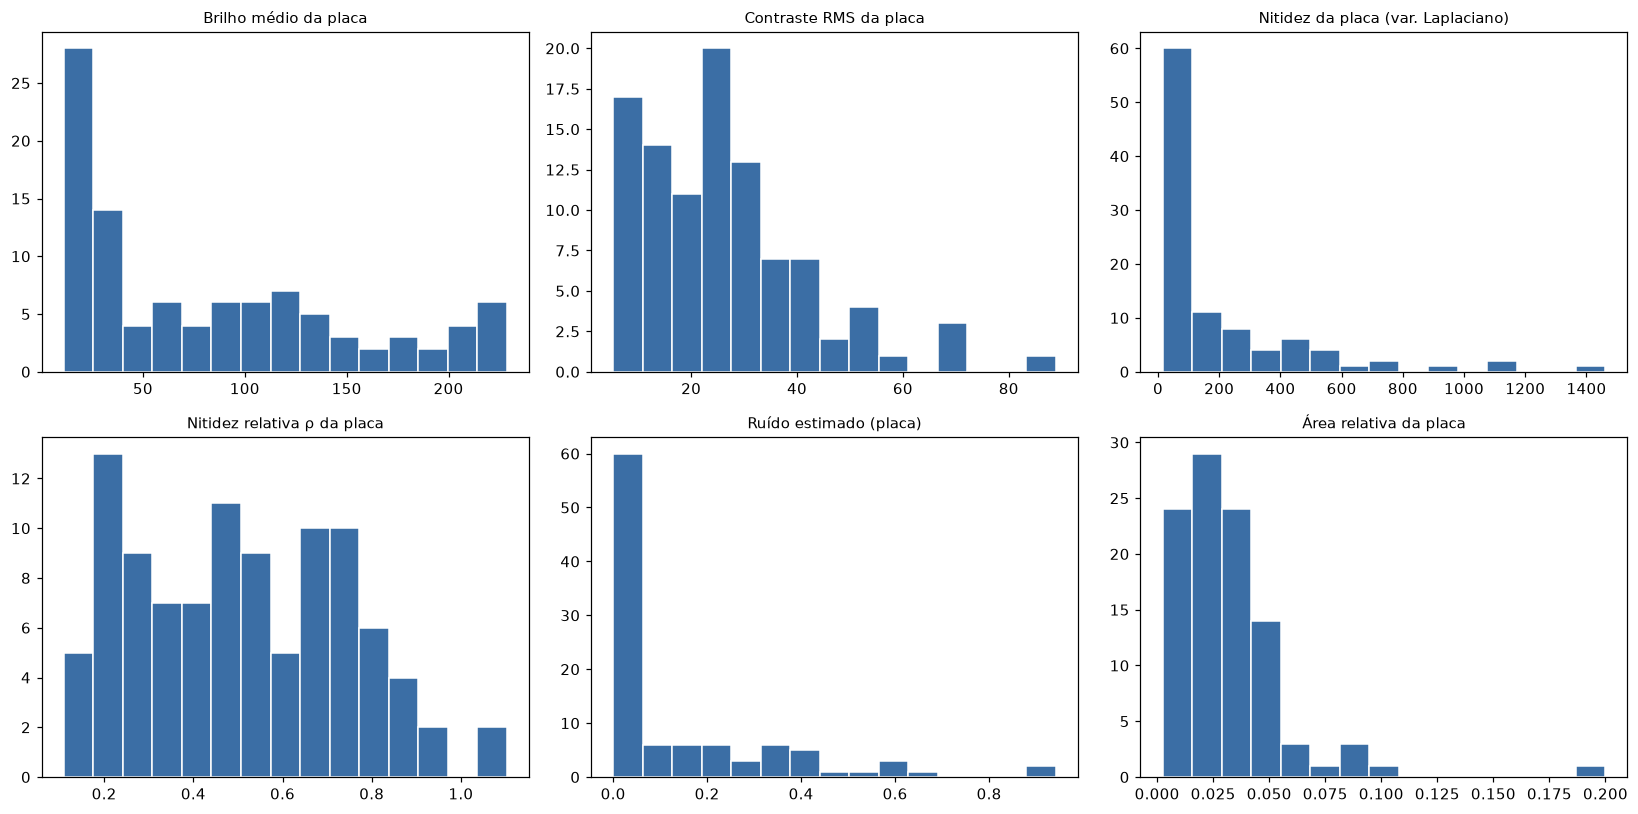

Placas com sigma de ruido estimado == 0: 0 de 100 (estimador wavelet colapsa em recortes pequenos e borrados — limitacao usada mais adiante)


In [4]:
hist_cols = [
    ("plate_brightness_mean", "Brilho médio da placa"),
    ("plate_contrast_std", "Contraste RMS da placa"),
    ("plate_sharpness_laplacian_var", "Nitidez da placa (var. Laplaciano)"),
    ("plate_relative_sharpness", "Nitidez relativa ρ da placa"),
    ("plate_noise_estimate", "Ruído estimado (placa)"),
    ("plate_plate_area_ratio", "Área relativa da placa"),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, (col, title) in zip(axes.flat, hist_cols):
    ax.hist(df[col], bins=15, color="#3b6ea5", edgecolor="white")
    ax.set_title(title, fontsize=10)
fig.tight_layout()
plt.show()

print(f"Placas com sigma de ruido estimado == 0: {(df['plate_noise_estimate'] == 0).sum()} de 100 "
      "(estimador wavelet colapsa em recortes pequenos e borrados — limitacao usada mais adiante)")

## 1.4 Validação cruzada com os metadados CCPD

Os autores do dataset já anotaram `brightness_ccpd` e `blur_ccpd`. Se nossas métricas medem o que dizem medir, devem correlacionar com essas anotações (positivo para brilho; negativo entre `blur_ccpd` e nitidez).

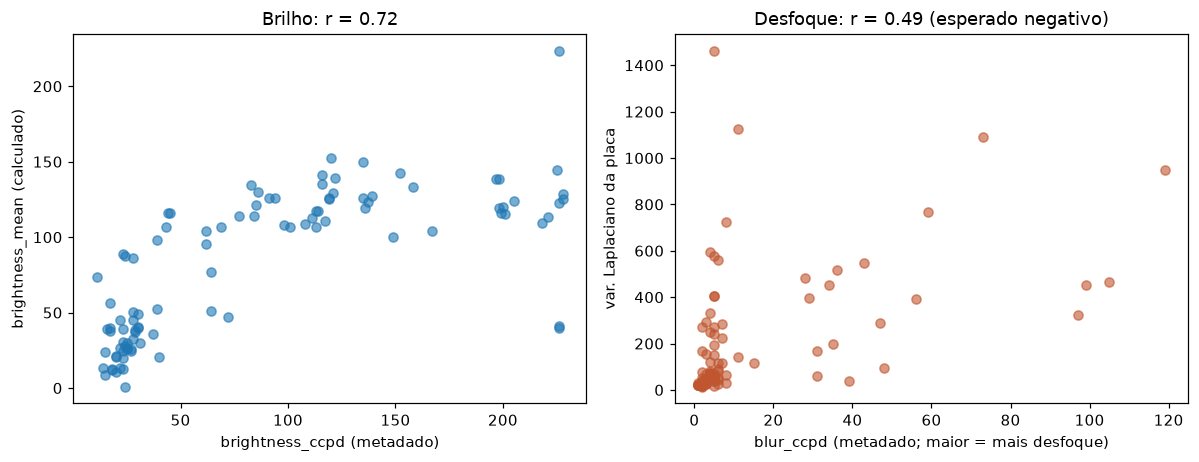

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
r_b = np.corrcoef(df["brightness_mean"], df["brightness_ccpd"])[0, 1]
axes[0].scatter(df["brightness_ccpd"], df["brightness_mean"], alpha=0.6)
axes[0].set_xlabel("brightness_ccpd (metadado)"); axes[0].set_ylabel("brightness_mean (calculado)")
axes[0].set_title(f"Brilho: r = {r_b:.2f}")
r_s = np.corrcoef(df["blur_ccpd"], df["plate_sharpness_laplacian_var"])[0, 1]
axes[1].scatter(df["blur_ccpd"], df["plate_sharpness_laplacian_var"], alpha=0.6, color="#c0562f")
axes[1].set_xlabel("blur_ccpd (metadado; maior = mais desfoque)"); axes[1].set_ylabel("var. Laplaciano da placa")
axes[1].set_title(f"Desfoque: r = {r_s:.2f} (esperado negativo)")
fig.tight_layout(); plt.show()

## 1.5 Extremos por métrica

Recortes da placa (com margem) nos extremos de cada métrica — onde os problemas ficam visíveis.

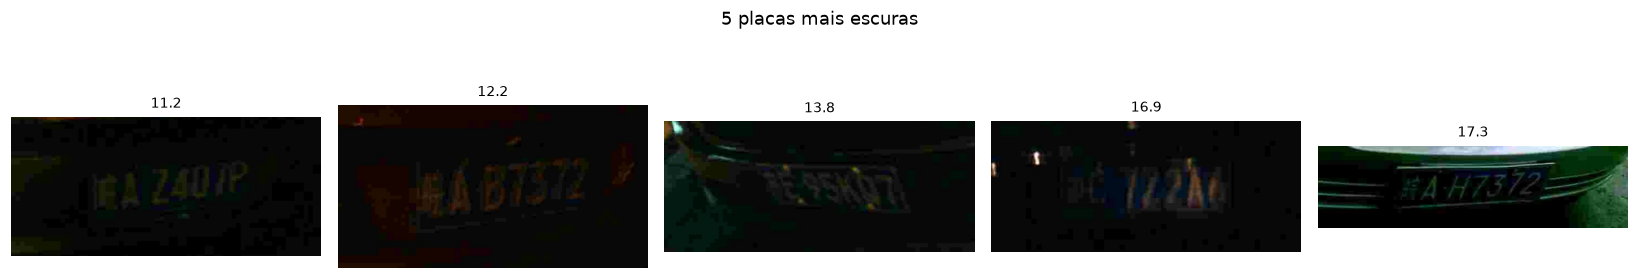

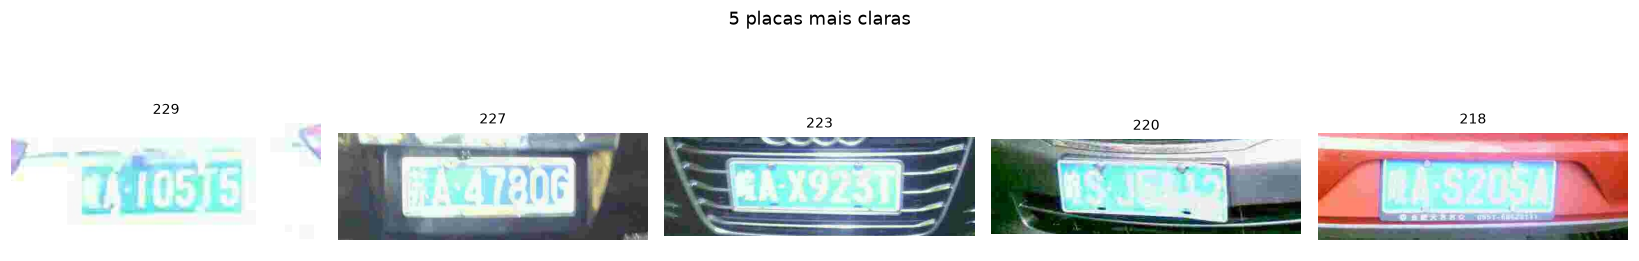

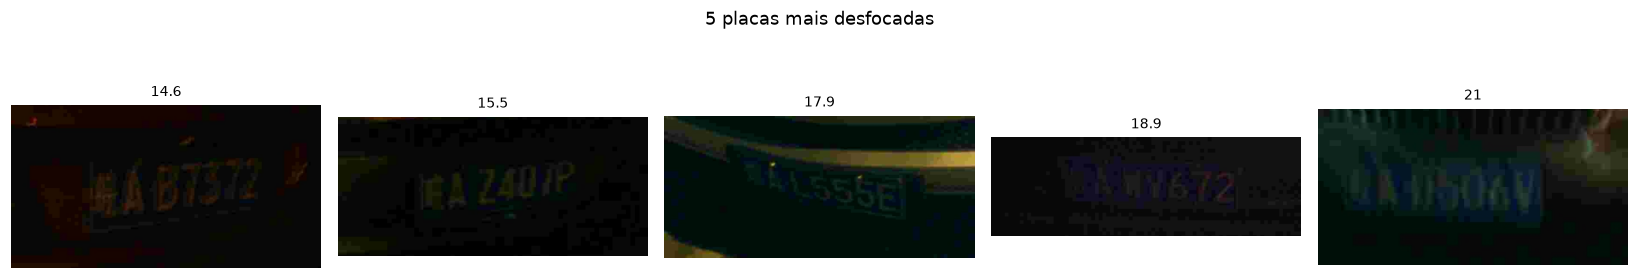

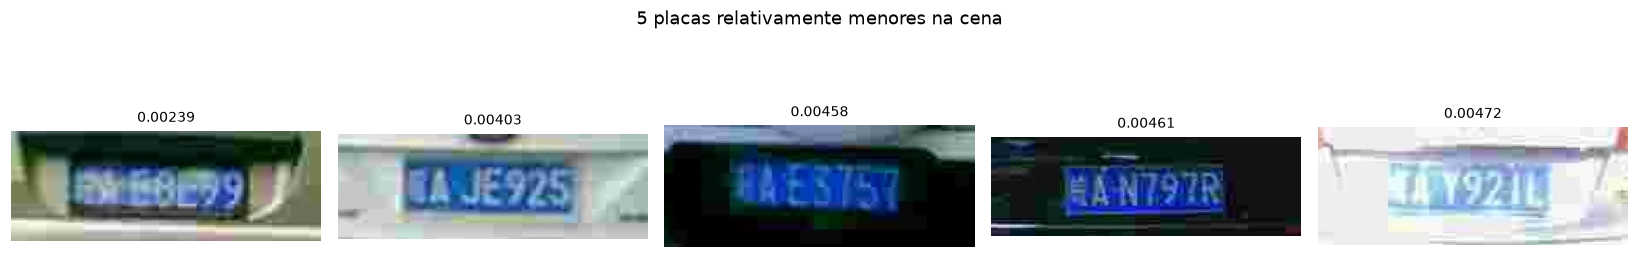

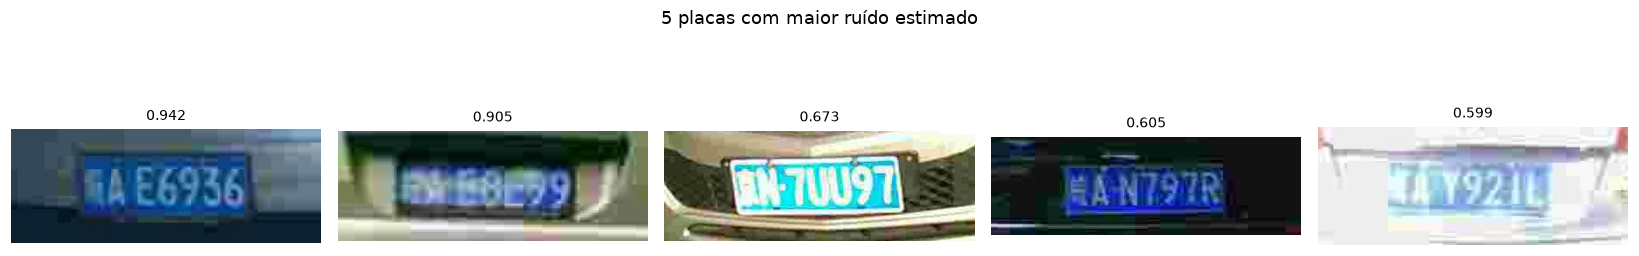

In [6]:
def crop_with_margin(img_bgr, bbox, margin_ratio=0.4):
    h, w = img_bgr.shape[:2]
    x1, y1, x2, y2 = bbox
    mx, my = int((x2 - x1) * margin_ratio), int((y2 - y1) * margin_ratio)
    x1, y1, x2, y2 = pp._clamp_bbox(x1 - mx, y1 - my, x2 + mx, y2 + my, w, h)
    crop = img_bgr[y1:y2, x1:x2]
    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB) if crop.ndim == 3 else crop

def show_extremes(metric, title, n=5, largest=True):
    subset = df.nlargest(n, metric) if largest else df.nsmallest(n, metric)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, (_, row) in zip(axes, subset.iterrows()):
        ax.imshow(crop_with_margin(load_bgr(row), bbox_of(row)))
        ax.set_title(f"{row[metric]:.3g}", fontsize=9); ax.axis("off")
    fig.suptitle(title); fig.tight_layout(); plt.show()

show_extremes("plate_brightness_mean", "5 placas mais escuras", largest=False)
show_extremes("plate_brightness_mean", "5 placas mais claras", largest=True)
show_extremes("plate_sharpness_laplacian_var", "5 placas mais desfocadas", largest=False)
show_extremes("plate_plate_area_ratio", "5 placas relativamente menores na cena", largest=False)
show_extremes("plate_noise_estimate", "5 placas com maior ruído estimado", largest=True)

## 1.6 Categorização por contexto de problema

Cada imagem pode ter mais de um problema. Para cada dimensão de qualidade marcamos a imagem se ela se desvia da média do dataset em mais de $0{,}5\,\sigma$ na direção ruim (medido no recorte da placa). Os limiares resultantes são **congelados como constantes absolutas** em `preprocessing_pipeline.py`, para que uma imagem isolada possa ser diagnosticada sem depender do lote.

BRIGHTNESS_LOW   calculado =  50.5557 | congelado no modulo = 50.56
BRIGHTNESS_HIGH  calculado = 117.1765 | congelado no modulo = 117.2
CONTRAST_LOW     calculado =  18.3537 | congelado no modulo = 18.35
SHARPNESS_LOW    calculado =  61.1285 | congelado no modulo = 61.13
NOISE_HIGH       calculado =   0.2357 | congelado no modulo = 0.2357
PLATE_AREA_LOW   calculado =   0.0182 | congelado no modulo = 0.01825


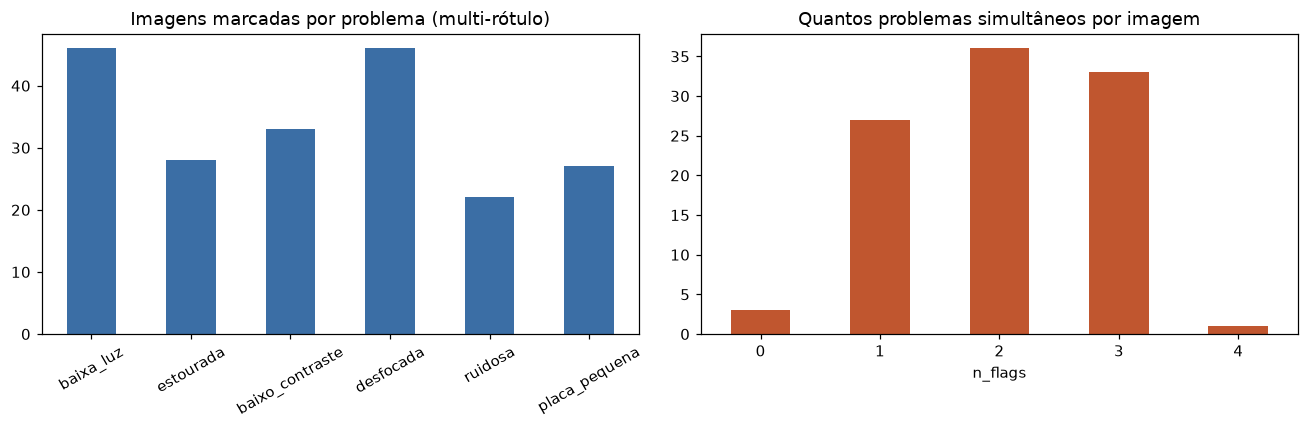

{'baixa_luz': 46, 'estourada': 28, 'baixo_contraste': 33, 'desfocada': 46, 'ruidosa': 22, 'placa_pequena': 27}


In [7]:
m, s = df.mean(numeric_only=True), df.std(numeric_only=True)
thresholds = {
    "BRIGHTNESS_LOW": m["plate_brightness_mean"] - 0.5 * s["plate_brightness_mean"],
    "BRIGHTNESS_HIGH": m["plate_brightness_mean"] + 0.5 * s["plate_brightness_mean"],
    "CONTRAST_LOW": m["plate_contrast_std"] - 0.5 * s["plate_contrast_std"],
    "SHARPNESS_LOW": m["plate_sharpness_laplacian_var"] - 0.5 * s["plate_sharpness_laplacian_var"],
    "NOISE_HIGH": m["plate_noise_estimate"] + 0.5 * s["plate_noise_estimate"],
    "PLATE_AREA_LOW": m["plate_plate_area_ratio"] - 0.5 * s["plate_plate_area_ratio"],
}
for k, v in thresholds.items():
    frozen = getattr(pp, k)
    assert np.isclose(v, frozen, rtol=1e-2), (k, v, frozen)
    print(f"{k:16s} calculado = {v:8.4f} | congelado no modulo = {frozen}")

CATS = ["baixa_luz", "estourada", "baixo_contraste", "desfocada", "ruidosa", "placa_pequena"]
flags_df = pd.DataFrame([pp.diagnose({
    "brightness_mean": r.plate_brightness_mean, "contrast_std": r.plate_contrast_std,
    "sharpness_laplacian_var": r.plate_sharpness_laplacian_var, "noise_estimate": r.plate_noise_estimate,
    "plate_area_ratio": r.plate_plate_area_ratio}) for r in df.itertuples()])
for c in CATS:
    df[f"flag_{c}"] = flags_df[c].values
df["n_flags"] = flags_df.sum(axis=1).values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
flags_df.sum().plot(kind="bar", ax=axes[0], color="#3b6ea5"); axes[0].set_title("Imagens marcadas por problema (multi-rótulo)")
axes[0].tick_params(axis="x", rotation=30)
df["n_flags"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#c0562f")
axes[1].set_title("Quantos problemas simultâneos por imagem"); axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout(); plt.show()
print(flags_df.sum().to_dict())

## 1.7 O que é — e o que não é — um filtro linear

Um operador $T$ é linear se $T(\alpha f + \beta g) = \alpha\,T(f) + \beta\,T(g)$. Todo filtro linear invariante ao deslocamento é uma **convolução**, e a composição de convoluções é **uma única convolução** (kernel efetivo $h = h_n * \cdots * h_1$). Isso dá duas propriedades que usamos diretamente no projeto:

1. a cadeia inteira de filtros espaciais pode ser inspecionada como **um kernel**;
2. a amplificação de ruído branco por um filtro linear é exatamente $\|h\|_2$ — não precisamos *estimar* ruído na saída, sabemos quanto o pipeline o multiplica.

| Ferramenta | Linear? | Por quê |
|---|---|---|
| conversão para cinza | ✓ | combinação fixa $0{,}299R+0{,}587G+0{,}114B$ |
| filtro média / gaussiano | ✓ | convolução com kernel positivo normalizado |
| Sobel, Laplaciano, unsharp mask | ✓ | convolução (unsharp $= (1+k)\delta - k\,G_\sigma$) |
| transformação afim $T(r)=ar+b$ (alargamento de contraste) | ✓ (afim) | uma reta; $a,b$ escalares |
| reamostragem bilinear / bicúbica / Lanczos | ✓ | filtro de reconstrução linear |
| **mediana** | ✗ | estatística de ordem |
| **bilateral, non-local means** | ✗ | pesos dependem do conteúdo |
| **equalização de histograma, CLAHE** | ✗ | mapeamento depende do histograma, não é uma reta |
| **gamma, log** | ✗ | curva de intensidade não-linear |
| **limiarização, morfologia, `detailEnhance`** | ✗ | decisão por pixel / operadores de ordem |

> O slide 7 do enunciado mostra um pipeline *exemplo* que inclui mediana, bilateral e CLAHE; o slide 10 e o critério de avaliação exigem **apenas filtros lineares**. Seguimos a regra explícita: a coluna da direita fica **fora** do pipeline. Sobre a transformação afim: os coeficientes $a,b$ são lidos das estatísticas da imagem, mas o operador aplicado a cada pixel é uma reta — é o "alargamento de contraste linear" clássico; o único ponto não-linear é o *clipping* final para `uint8`, inevitável em qualquer saída de 8 bits.

Abaixo verificamos numericamente a linearidade da cadeia de convoluções, mostramos o kernel efetivo do Pipeline A e o seu ganho de ruído $\|h\|_2$.

max |T(af+bg) - (aT(f)+bT(g))| = 1.22e-04  ->  linear: True


soma do kernel efetivo = 1.0000 (preserva o nivel medio) | ganho de ruido ||h||2 = 1.978


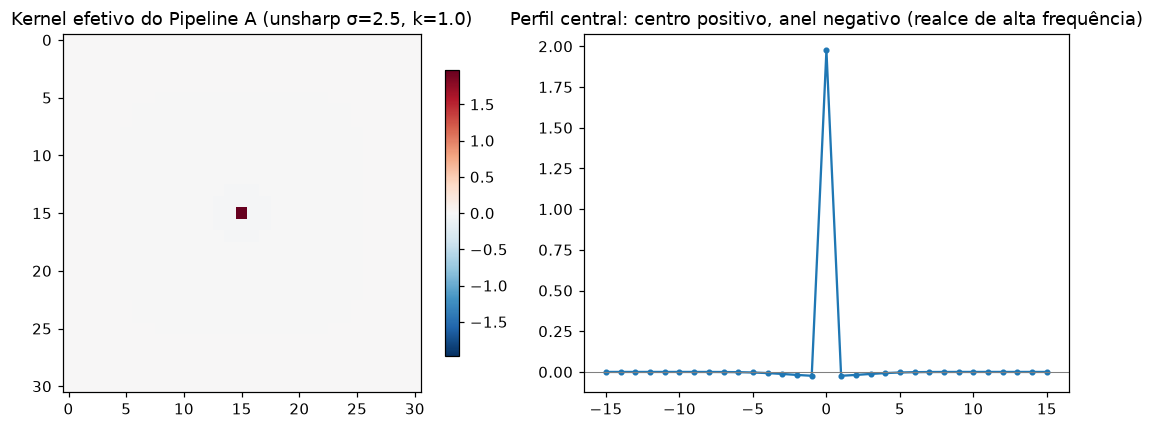

In [8]:
err, ok = pp.check_linearity(pp.GLOBAL_PARAMS)
print(f"max |T(af+bg) - (aT(f)+bT(g))| = {err:.2e}  ->  linear: {ok}")
assert ok

h = pp.effective_kernel(pp.GLOBAL_PARAMS, size=31)
print(f"soma do kernel efetivo = {h.sum():.4f} (preserva o nivel medio) | ganho de ruido ||h||2 = {pp.kernel_noise_gain():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].imshow(h, cmap="RdBu_r", vmin=-np.abs(h).max(), vmax=np.abs(h).max())
axes[0].set_title("Kernel efetivo do Pipeline A (unsharp σ=2.5, k=1.0)"); fig.colorbar(im, ax=axes[0], shrink=0.8)
axes[1].plot(np.arange(-15, 16), h[15, :], marker="o", ms=3)
axes[1].axhline(0, color="gray", lw=0.7); axes[1].set_title("Perfil central: centro positivo, anel negativo (realce de alta frequência)")
fig.tight_layout(); plt.show()

## 1.8 Comparação de candidatos **lineares** por contexto

Para cada contexto, pegamos a imagem mais extrema naquele problema e comparamos candidatos lineares no recorte da placa, com métricas antes/depois — não só inspeção visual. Só entram ferramentas da coluna "✓" da tabela acima.

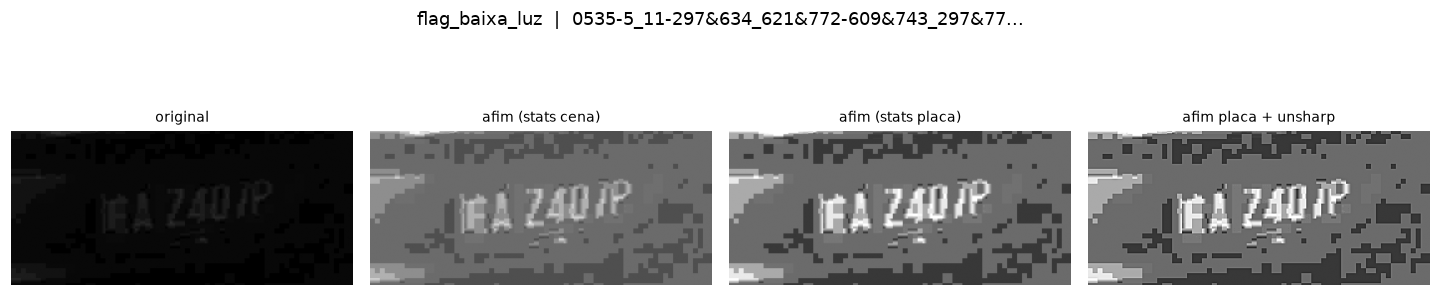

,brilho,contraste,nitidez_rel,saturacao_%,ganho_contraste,retencao_nitidez
candidato,,,,,,
original,11.190,7.052,0.557,3.818,1.000,1.000
afim (stats cena),118.213,24.705,0.556,0.000,3.503,0.998
afim (stats placa),126.776,43.559,0.547,1.232,6.177,0.981
afim placa + unsharp,126.209,47.350,0.910,2.863,6.715,1.632


In [9]:
def run_on(img_bgr, bbox, params, stats_from_plate):
    out, _ = pp.run_linear_pipeline(img_bgr, params, stats_bbox=bbox if stats_from_plate else None)
    return out

def compare_context(flag_col, sort_col, ascending, candidates):
    subset = df[df[flag_col]]
    row = subset.sort_values(sort_col, ascending=ascending).iloc[0]
    img, bbox = load_bgr(row), bbox_of(row)
    outputs = {"original": pp.to_gray(img)}
    for name, (params, plate_stats) in candidates.items():
        outputs[name] = run_on(img, bbox, params, plate_stats)

    fig, axes = plt.subplots(1, len(outputs), figsize=(3.3 * len(outputs), 3.4))
    for ax, (name, out) in zip(axes, outputs.items()):
        ax.imshow(crop_with_margin(out, bbox), cmap="gray", vmin=0, vmax=255); ax.set_title(name, fontsize=9); ax.axis("off")
    fig.suptitle(f"{flag_col}  |  {row['filename'][:40]}..."); fig.tight_layout(); plt.show()

    base = pp.compute_metrics(outputs["original"], bbox=bbox)
    table = []
    for name, out in outputs.items():
        mt = pp.compute_metrics(out, bbox=bbox)
        table.append({"candidato": name, "brilho": mt["brightness_mean"], "contraste": mt["contrast_std"],
                      "nitidez_rel": mt["relative_sharpness"], "saturacao_%": 100 * mt["clipped_fraction"],
                      "ganho_contraste": mt["contrast_std"] / base["contrast_std"],
                      "retencao_nitidez": mt["relative_sharpness"] / base["relative_sharpness"]})
    return pd.DataFrame(table).set_index("candidato").round(3)

P = pp.PipelineParams
compare_context("flag_baixa_luz", "plate_brightness_mean", True, {
    "afim (stats cena)": (P(0, 127, 60, 2.5, 0), False),
    "afim (stats placa)": (P(0, 127, 45, 2.5, 0), True),
    "afim placa + unsharp": (P(0, 127, 45, 1.5, 1.0), True),
})

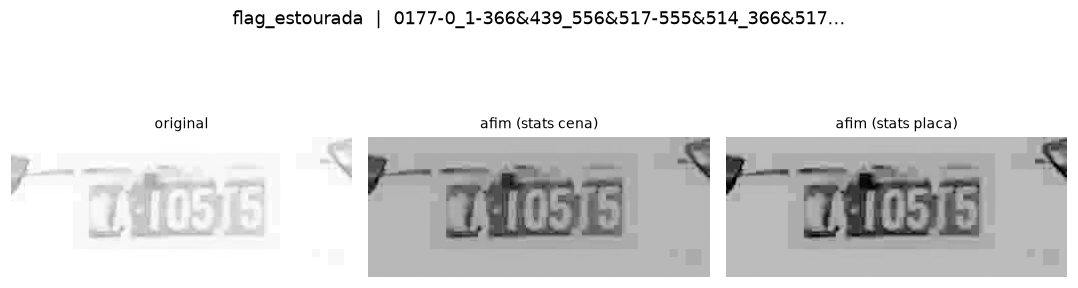

,brilho,contraste,nitidez_rel,saturacao_%,ganho_contraste,retencao_nitidez
candidato,,,,,,
original,228.530,19.580,0.554,0.412,1.000,1.000
afim (stats cena),136.191,35.348,0.555,0.000,1.805,1.001
afim (stats placa),127.058,44.933,0.554,0.189,2.295,0.998


In [10]:
compare_context("flag_estourada", "plate_brightness_mean", False, {
    "afim (stats cena)": (P(0, 127, 60, 2.5, 0), False),
    "afim (stats placa)": (P(0, 127, 45, 2.5, 0), True),
})

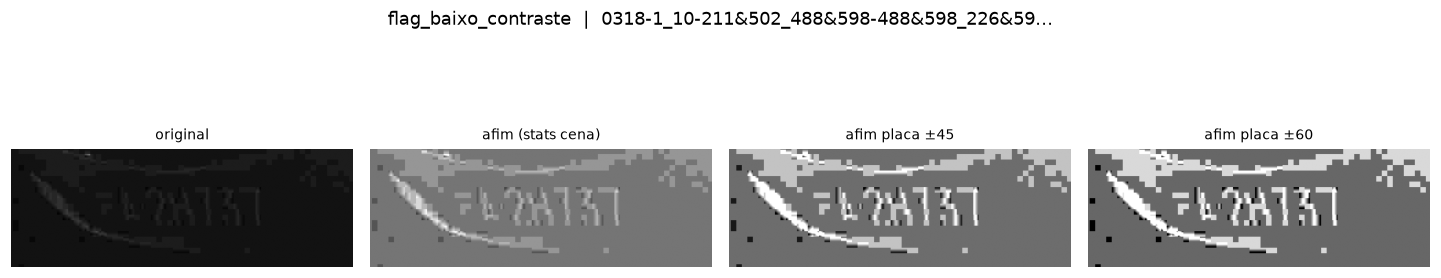

,brilho,contraste,nitidez_rel,saturacao_%,ganho_contraste,retencao_nitidez
candidato,,,,,,
original,20.085,5.263,0.877,0.000,1.000,1.000
afim (stats cena),123.930,17.382,0.869,0.019,3.303,0.991
afim placa ±45,126.032,41.635,0.875,3.057,7.912,0.998
afim placa ±60,124.186,50.779,0.882,4.998,9.649,1.006


In [11]:
compare_context("flag_baixo_contraste", "plate_contrast_std", True, {
    "afim (stats cena)": (P(0, 127, 60, 2.5, 0), False),
    "afim placa ±45": (P(0, 127, 45, 2.5, 0), True),
    "afim placa ±60": (P(0, 127, 60, 2.5, 0), True),
})

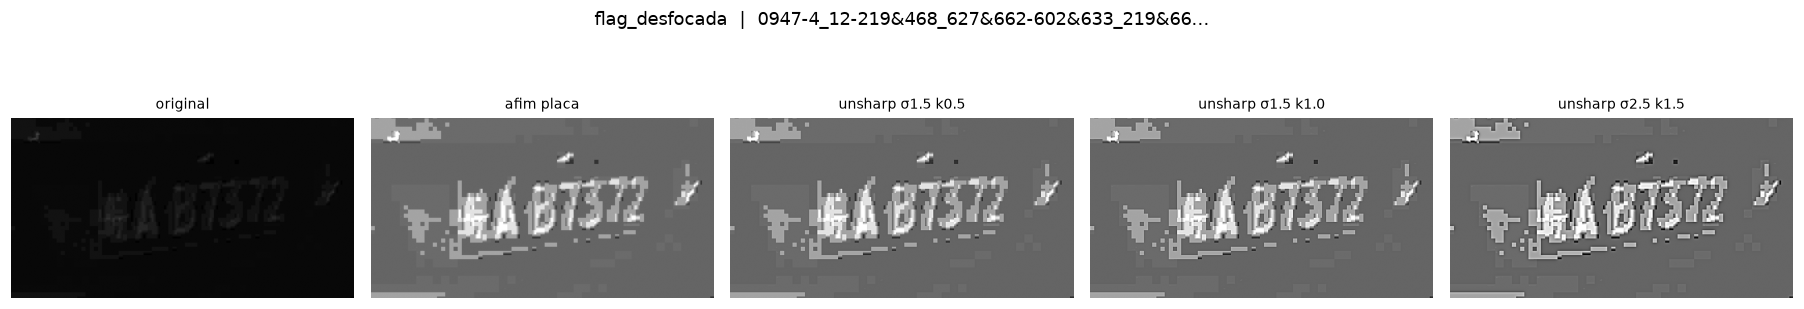

,brilho,contraste,nitidez_rel,saturacao_%,ganho_contraste,retencao_nitidez
candidato,,,,,,
original,12.185,7.131,0.536,0.604,1.000,1.000
afim placa,126.764,43.058,0.535,1.890,6.038,0.997
unsharp σ1.5 k0.5,126.495,44.740,0.753,1.947,6.274,1.405
unsharp σ1.5 k1.0,126.279,46.626,0.936,2.496,6.539,1.746
unsharp σ2.5 k1.5,125.320,52.219,1.014,4.844,7.323,1.891


In [12]:
compare_context("flag_desfocada", "plate_sharpness_laplacian_var", True, {
    "afim placa": (P(0, 127, 45, 1.5, 0), True),
    "unsharp σ1.5 k0.5": (P(0, 127, 45, 1.5, 0.5), True),
    "unsharp σ1.5 k1.0": (P(0, 127, 45, 1.5, 1.0), True),
    "unsharp σ2.5 k1.5": (P(0, 127, 45, 2.5, 1.5), True),
})

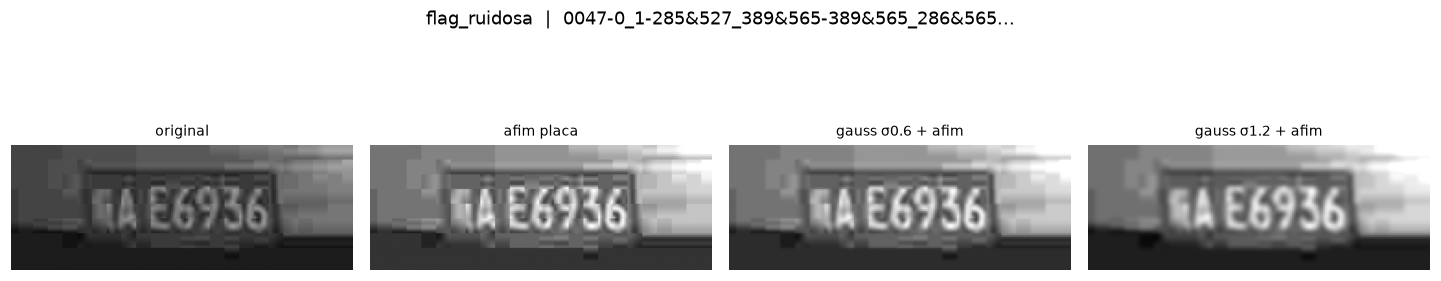

,brilho,contraste,nitidez_rel,saturacao_%,ganho_contraste,retencao_nitidez
candidato,,,,,,
original,74.900,27.629,0.855,0.000,1.000,1.000
afim placa,126.959,45.005,0.854,0.127,1.629,0.998
gauss σ0.6 + afim,126.997,45.008,0.590,0.000,1.629,0.690
gauss σ1.2 + afim,127.002,45.000,0.356,0.000,1.629,0.416


In [13]:
compare_context("flag_ruidosa", "plate_noise_estimate", False, {
    "afim placa": (P(0, 127, 45, 1.5, 0), True),
    "gauss σ0.6 + afim": (P(0.6, 127, 45, 1.5, 0), True),
    "gauss σ1.2 + afim": (P(1.2, 127, 45, 1.5, 0), True),
})

## 1.9 Hipótese de resolução

O que a análise sugere antes de calibrar qualquer coisa:

* **Brilho e contraste** são o problema dominante (baixa luz, estourada e baixo contraste juntos marcam a maior parte do dataset) e têm uma solução linear direta: a transformação afim $T(r)=ar+b$. A comparação acima mostra que **de onde vêm as estatísticas** ($\mu,\sigma$ da cena vs. do recorte da placa) muda o resultado mais do que qualquer outro parâmetro — o fundo da cena e a placa raramente têm o mesmo brilho.
* **Desfoque** responde ao unsharp mask (única ferramenta linear que realça alta frequência), ao custo de overshoot nas bordas (saturação).
* **Ruído**: a única ferramenta linear é suavizar (gaussiana), o que necessariamente derruba a nitidez; e o estimador de ruído colapsa a zero em muitas placas, então o diagnóstico "ruidosa" é frágil.
* **Placa pequena**: nenhum filtro linear cria resolução; fica como limite conhecido.

Daí os dois pipelines a comparar: **A (global, fixo, sem anotação)** responde à pergunta do enunciado; **B (mesmos blocos, estatísticas da placa, unsharp condicionado ao diagnóstico)** mede quanto se ganha ao adaptar.

# Parte 2 — Implementação

## 2.1 Diagrama de blocos das pipelines

Os dois pipelines compartilham os quatro blocos (todos lineares). O código de cada bloco está em `preprocessing_pipeline.py`: `to_gray`, `gaussian_smooth`, `affine_intensity`, `unsharp_mask`; a cadeia em `run_linear_pipeline`.

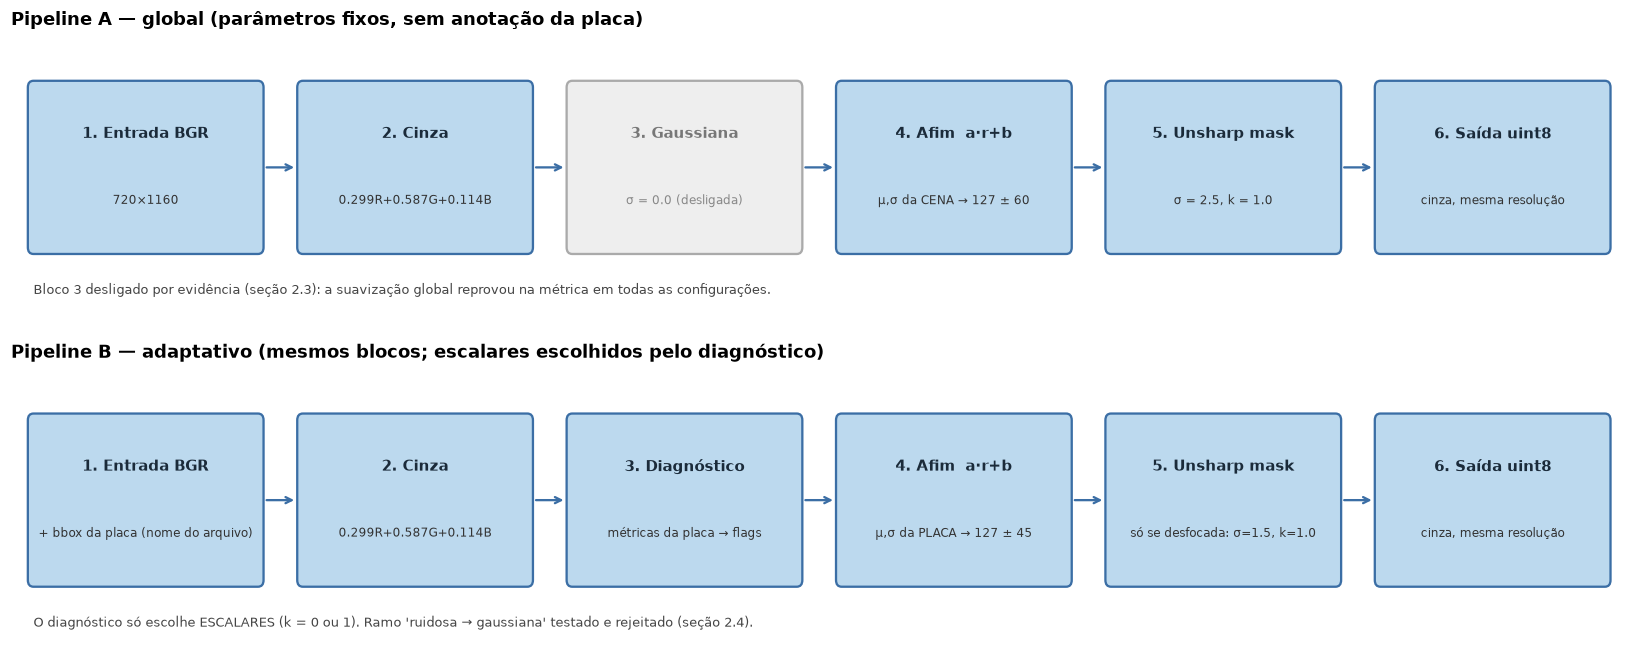

In [14]:
def draw_pipeline(ax, title, blocks, note):
    n = len(blocks)
    ax.set_xlim(0, n * 2.4); ax.set_ylim(0, 2.2); ax.axis("off")
    ax.set_title(title, fontsize=12, loc="left", fontweight="bold")
    for i, (label, sub, active) in enumerate(blocks):
        x = i * 2.4 + 0.2
        color = "#bcd9ee" if active else "#eeeeee"
        edge = "#3b6ea5" if active else "#aaaaaa"
        ax.add_patch(mpatches.FancyBboxPatch((x, 0.6), 2.0, 1.2, boxstyle="round,pad=0.05", fc=color, ec=edge, lw=1.5))
        ax.text(x + 1.0, 1.45, label, ha="center", va="center", fontsize=9.5, fontweight="bold",
                color="#1b2b3a" if active else "#777777")
        ax.text(x + 1.0, 0.95, sub, ha="center", va="center", fontsize=8, color="#333333" if active else "#888888")
        if i < n - 1:
            ax.annotate("", xy=(x + 2.35, 1.2), xytext=(x + 2.05, 1.2), arrowprops=dict(arrowstyle="->", lw=1.5, color="#3b6ea5"))
    ax.text(0.2, 0.25, note, fontsize=8.5, color="#444444")

gp = pp.GLOBAL_PARAMS
fig, axes = plt.subplots(2, 1, figsize=(15, 6.2))
draw_pipeline(axes[0], "Pipeline A — global (parâmetros fixos, sem anotação da placa)", [
    ("1. Entrada BGR", "720×1160", True),
    ("2. Cinza", "0.299R+0.587G+0.114B", True),
    ("3. Gaussiana", f"σ = {gp.smooth_sigma} (desligada)", gp.smooth_sigma > 0),
    ("4. Afim  a·r+b", f"μ,σ da CENA → {gp.target_mean:.0f} ± {gp.target_std:.0f}", True),
    ("5. Unsharp mask", f"σ = {gp.sharpen_sigma}, k = {gp.sharpen_amount}", True),
    ("6. Saída uint8", "cinza, mesma resolução", True),
], "Bloco 3 desligado por evidência (seção 2.3): a suavização global reprovou na métrica em todas as configurações.")

ab = pp.ADAPTIVE_BASE
draw_pipeline(axes[1], "Pipeline B — adaptativo (mesmos blocos; escalares escolhidos pelo diagnóstico)", [
    ("1. Entrada BGR", "+ bbox da placa (nome do arquivo)", True),
    ("2. Cinza", "0.299R+0.587G+0.114B", True),
    ("3. Diagnóstico", "métricas da placa → flags", True),
    ("4. Afim  a·r+b", f"μ,σ da PLACA → {ab.target_mean:.0f} ± {ab.target_std:.0f}", True),
    ("5. Unsharp mask", f"só se desfocada: σ={ab.sharpen_sigma}, k={pp.ADAPTIVE_SHARPEN_AMOUNT}", True),
    ("6. Saída uint8", "cinza, mesma resolução", True),
], "O diagnóstico só escolhe ESCALARES (k = 0 ou 1). Ramo 'ruidosa → gaussiana' testado e rejeitado (seção 2.4).")
fig.tight_layout(); plt.show()

## 2.2 Métrica de avaliação proposta — Índice de Legibilidade Linear (ILL)

Definida **antes** da calibração, para não ser ajustada ao resultado. Tudo é medido no **recorte da placa**, comparando entrada e saída ("meça nos dois eixos, compare entrada/saída"):

| eixo | grandeza | condição de sucesso |
|---|---|---|
| **1 — contraste** | ganho de contraste $g_c = \sigma_{\text{depois}}/\sigma_{\text{antes}}$ | $g_c > 1$ |
| **2 — estrutura** | retenção de nitidez $g_\rho = \rho_{\text{depois}}/\rho_{\text{antes}}$, com $\rho=\sigma(\nabla^2 I)/\sigma(I)$ (invariante afim) | $g_\rho \ge 0{,}9$ |
| custo de artefato | fração de pixels saturados (0 ou 255) no recorte | $< 5\%$ |
| custo de artefato | brilho médio da placa | em $[40, 215]$ |

$$\text{ILL} = \log_2 g_c + \log_2 \min(g_\rho, 1)$$

ILL $>0$ significa que a placa ganhou contraste sem perder estrutura. A **taxa de sucesso** (fração das 100 imagens que cumprem as quatro condições) é o número que usamos para responder se um pipeline "serve a todas". A retenção usa $\rho$ e não a variância bruta do Laplaciano justamente porque esta cresce com $a^2$ em qualquer alargamento de contraste — o que faria um pipeline puramente tonal parecer "mais nítido".

**Limitação conhecida (declarada antes de medir):** $\rho$ não distingue borda de ruído. Um filtro que remove ruído legítimo reduz $\rho$ e é penalizado; a métrica é, portanto, conservadora com denoising. Sem *ground truth* de OCR essa é a troca que aceitamos.

In [15]:
print(pp.evaluate_pair.__doc__)

# exemplo sintetico: placa "ideal" escura e de baixo contraste -> apenas afim
rng = np.random.default_rng(0)
synthetic = (30 + 12 * (rng.random((40, 120)) > 0.5)).astype(np.uint8)
before = pp.compute_metrics(synthetic)
a, b = pp.affine_coefficients(synthetic, 127, 45)
after = pp.compute_metrics(pp.to_uint8(pp.affine_intensity(synthetic, a, b)))
print({k: round(v, 3) for k, v in pp.evaluate_pair(before, after).items()})

Metrica proposta — Indice de Legibilidade Linear (ILL), medida no recorte
da placa, comparando entrada e saida em dois eixos:

* eixo 1, contraste:  ganho_contraste = sigma_depois / sigma_antes
* eixo 2, estrutura:  retencao_nitidez = rho_depois / rho_antes, com
                      rho = sigma(Laplaciano) / sigma(imagem)  (invariante afim)

e um custo de artefato: fracao de pixels saturados (0 ou 255) e brilho
medio da placa dentro de uma faixa legivel.

ILL = log2(ganho_contraste) + log2(min(retencao_nitidez, 1))
sucesso := ganho_contraste > 1  e  retencao >= 0.9  e  saturacao < 5 %
           e  brilho da placa em [40, 215].

{'contrast_gain': 7.5, 'sharpness_retention': 1.0, 'clipped_fraction_after': 0.0, 'ill': 2.907, 'success': 1}


## 2.3 Calibração do Pipeline A por busca em grade

Grade sobre os 4 escalares do pipeline (σ da gaussiana, σ-alvo da afim, σ e k do unsharp), 108 configurações × 100 imagens, escolhendo a que maximiza a **taxa de sucesso** e, em empate, a mediana do ILL. Estatísticas da afim sempre lidas da cena inteira (o pipeline global não conhece a placa).

In [16]:
imgs = [(load_bgr(r), bbox_of(r)) for _, r in df.iterrows()]
befores = [pp.compute_metrics(im, bbox=bb) for im, bb in imgs]

def evaluate_config(params, stats_from_plate, extra_flag_rule=None):
    rows = []
    for (im, bb), b, fl in zip(imgs, befores, flags_df.to_dict("records")):
        p = params if extra_flag_rule is None else extra_flag_rule(params, fl)
        out, _ = pp.run_linear_pipeline(im, p, stats_bbox=bb if stats_from_plate else None)
        rows.append(pp.evaluate_pair(b, pp.compute_metrics(out, bbox=bb)))
    d = pd.DataFrame(rows)
    return {"taxa_sucesso": d["success"].mean(), "ill_mediano": d["ill"].median(),
            "ganho_contraste_med": d["contrast_gain"].median(), "retencao_med": d["sharpness_retention"].median(),
            "saturacao_med_%": 100 * d["clipped_fraction_after"].median()}

grid = []
for ss, ts, sh_s, sh_a in itertools.product([0.0, 0.6, 1.0], [40, 50, 60], [1.0, 1.5, 2.5], [0.0, 0.5, 1.0, 1.5]):
    res = evaluate_config(pp.PipelineParams(ss, 127, ts, sh_s, sh_a), stats_from_plate=False)
    grid.append({"gauss_sigma": ss, "afim_std": ts, "unsharp_sigma": sh_s, "unsharp_k": sh_a, **res})
grid_df = pd.DataFrame(grid).sort_values(["taxa_sucesso", "ill_mediano"], ascending=False).reset_index(drop=True)
best = grid_df.iloc[0]
print("Melhor configuracao da grade:", best[["gauss_sigma", "afim_std", "unsharp_sigma", "unsharp_k", "taxa_sucesso"]].to_dict())
assert (best["gauss_sigma"], best["afim_std"], best["unsharp_sigma"], best["unsharp_k"]) == \
       (gp.smooth_sigma, gp.target_std, gp.sharpen_sigma, gp.sharpen_amount), "GLOBAL_PARAMS do modulo divergem da grade"
grid_df.head(10).round(3)

Melhor configuracao da grade: {'gauss_sigma': 0.0, 'afim_std': 60.0, 'unsharp_sigma': 2.5, 'unsharp_k': 1.0, 'taxa_sucesso': 0.61}


,gauss_sigma,afim_std,unsharp_sigma,unsharp_k,taxa_sucesso,ill_mediano,ganho_contraste_med,retencao_med,saturacao_med_%
0,0.0,60,2.5,1.0,0.61,0.640,1.559,1.626,0.163
1,0.0,60,2.5,1.5,0.60,0.779,1.716,1.835,0.517
2,0.0,60,1.5,1.5,0.60,0.599,1.515,2.000,0.142
3,0.0,50,2.5,1.5,0.59,0.522,1.436,1.833,0.149
4,0.0,60,1.5,1.0,0.59,0.480,1.395,1.714,0.067
5,0.6,60,1.5,1.5,0.58,0.495,1.410,1.123,0.031
6,0.0,60,1.0,1.5,0.58,0.459,1.374,1.979,0.065
7,0.0,60,2.5,0.5,0.57,0.473,1.388,1.350,0.020
8,0.0,60,1.0,1.0,0.57,0.402,1.321,1.674,0.019
9,0.0,60,1.5,0.5,0.57,0.390,1.311,1.385,0.005


In [17]:
print("Efeito da suavizacao gaussiana global (media sobre as demais combinacoes):")
print(grid_df.groupby("gauss_sigma")[["taxa_sucesso", "retencao_med"]].mean().round(3))
print()
print("Efeito da forca do unsharp mask (media sobre as demais combinacoes):")
print(grid_df.groupby("unsharp_k")[["taxa_sucesso", "ganho_contraste_med", "retencao_med", "saturacao_med_%"]].mean().round(3))

Efeito da suavizacao gaussiana global (media sobre as demais combinacoes):
             taxa_sucesso  retencao_med
gauss_sigma                            
0.0                 0.495         1.495
0.6                 0.193         0.857
1.0                 0.000         0.506

Efeito da forca do unsharp mask (media sobre as demais combinacoes):
           taxa_sucesso  ganho_contraste_med  retencao_med  saturacao_med_%
unsharp_k                                                                  
0.0               0.148                1.004         0.672            0.000
0.5               0.160                1.065         0.873            0.001
1.0               0.264                1.134         1.053            0.012
1.5               0.346                1.208         1.212            0.044


## 2.4 Calibração do Pipeline B — ablação

Mesmos blocos; mudamos uma coisa por vez para saber **de onde vem o ganho**: (i) origem das estatísticas da afim (cena → placa); (ii) unsharp condicionado ao diagnóstico de desfoque, variando k; (iii) gaussiana condicionada ao diagnóstico de ruído.

In [18]:
def rule_sharpen_if_blurry(k, sigma):
    def rule(params, fl):
        p = pp.PipelineParams(**params.__dict__)
        if fl["desfocada"]:
            p.sharpen_amount = k; p.sharpen_sigma = sigma
        return p
    return rule

def rule_smooth_if_noisy(sig):
    def rule(params, fl):
        p = pp.PipelineParams(**params.__dict__)
        if fl["ruidosa"]:
            p.smooth_sigma = sig
        return p
    return rule

base_plate = pp.PipelineParams(0.0, 127, 45, 1.5, 0.0)
ablation = [
    ("A: afim cena 127±60 + unsharp (global)", evaluate_config(pp.GLOBAL_PARAMS, False)),
    ("afim cena 127±60, sem filtro espacial", evaluate_config(pp.PipelineParams(0, 127, 60, 1.5, 0), False)),
    ("afim PLACA 127±45, sem filtro espacial", evaluate_config(base_plate, True)),
    ("afim PLACA 127±60, sem filtro espacial", evaluate_config(pp.PipelineParams(0, 127, 60, 1.5, 0), True)),
    ("afim placa + unsharp em TODAS (σ1.5 k1.0)", evaluate_config(pp.PipelineParams(0, 127, 45, 1.5, 1.0), True)),
    ("afim placa + unsharp se desfocada (σ1.5 k0.5)", evaluate_config(base_plate, True, rule_sharpen_if_blurry(0.5, 1.5))),
    ("B: afim placa + unsharp se desfocada (σ1.5 k1.0)", evaluate_config(base_plate, True, rule_sharpen_if_blurry(1.0, 1.5))),
    ("afim placa + unsharp se desfocada (σ2.5 k1.0)", evaluate_config(base_plate, True, rule_sharpen_if_blurry(1.0, 2.5))),
    ("afim placa + gauss σ0.6 se ruidosa", evaluate_config(base_plate, True, rule_smooth_if_noisy(0.6))),
    ("afim placa + gauss σ1.2 se ruidosa", evaluate_config(base_plate, True, rule_smooth_if_noisy(1.2))),
]
ablation_df = pd.DataFrame([{"configuracao": n, **r} for n, r in ablation]).set_index("configuracao").round(3)
ablation_df

,taxa_sucesso,ill_mediano,ganho_contraste_med,retencao_med,saturacao_med_%
configuracao,,,,,
A: afim cena 127±60 + unsharp (global),0.61,0.640,1.559,1.626,0.163
"afim cena 127±60, sem filtro espacial",0.55,0.291,1.223,1.003,0.000
"afim PLACA 127±45, sem filtro espacial",0.88,0.810,1.753,1.001,0.604
"afim PLACA 127±60, sem filtro espacial",0.71,1.172,2.270,1.002,3.688
afim placa + unsharp em TODAS (σ1.5 k1.0),0.88,0.988,1.983,1.710,1.979
afim placa + unsharp se desfocada (σ1.5 k0.5),0.88,0.814,1.760,1.097,0.803
B: afim placa + unsharp se desfocada (σ1.5 k1.0),0.88,0.816,1.762,1.097,1.060
afim placa + unsharp se desfocada (σ2.5 k1.0),0.82,0.837,1.791,1.097,1.215
afim placa + gauss σ0.6 se ruidosa,0.72,0.784,1.753,0.998,0.589


Leitura da ablação (números na tabela acima):

* Trocar a **origem das estatísticas** da afim (cena → placa), sem nenhum filtro espacial, é o maior salto isolado de taxa de sucesso do experimento inteiro.
* O unsharp mask (σ=1.5, k=1.0) **não muda a taxa de sucesso** — aplicado a todas ou só às desfocadas, ela fica igual à da afim pura — mas eleva a retenção de nitidez das placas desfocadas. Preferimos a versão **condicionada** por parcimônia: mesma taxa, metade da saturação mediana, e as placas já nítidas saem do pipeline sem nenhum filtro espacial. Com σ=2.5 o overshoot já derruba a taxa.
* A gaussiana condicionada a "ruidosa" **piora** a taxa de sucesso em ambas as forças: pela nossa métrica (que não separa ruído de borda) e com um diagnóstico de ruído frágil (estimador colapsa a 0 em muitas placas), não há evidência para ligá-la. Fica documentada e desligada.

## 2.5 Execução sobre as 100 imagens

`process_folder` aplica o pipeline, grava a imagem processada com o **mesmo nome** da original e persiste em SQLite (`mapping.db`) a relação original ↔ processada, flags de diagnóstico, parâmetros usados, coeficientes $(a,b)$ e todas as métricas antes/depois.

In [19]:
for folder in (OUT_GLOBAL, OUT_ADAPTIVE):
    folder.mkdir(exist_ok=True)
    for old in folder.glob("*"):
        old.unlink()

res_A = pp.process_folder(IMAGES_DIR, OUT_GLOBAL, pipeline="global", db_path=OUT_GLOBAL / "mapping.db")
res_B = pp.process_folder(IMAGES_DIR, OUT_ADAPTIVE, pipeline="adaptive", db_path=OUT_ADAPTIVE / "mapping.db")

for name, folder in (("A", OUT_GLOBAL), ("B", OUT_ADAPTIVE)):
    produced = sorted(p.name for p in folder.glob("*.jpg"))
    assert len(produced) == 100 and produced == sorted(f.name for f in files), name
    conn = sqlite3.connect(folder / "mapping.db")
    n_rows = conn.execute("SELECT COUNT(*) FROM image_mapping").fetchone()[0]
    conn.close()
    assert n_rows == 100, name
    sample = cv2.imread(str(folder / produced[0]), cv2.IMREAD_UNCHANGED)
    print(f"Pipeline {name}: 100 imagens em {folder}/ (mesmos nomes) | {n_rows} linhas em mapping.db | "
          f"saida {sample.shape} {sample.dtype}")

Pipeline A: 100 imagens em images_processed_global/ (mesmos nomes) | 100 linhas em mapping.db | saida (1160, 720) uint8
Pipeline B: 100 imagens em images_processed/ (mesmos nomes) | 100 linhas em mapping.db | saida (1160, 720) uint8


## 2.6 Uma imagem, estágio a estágio (Pipeline A)

0359-1_2-284&446_550&559-550&559_287&553_284&...  afim: a = 3.056, b = 88.6


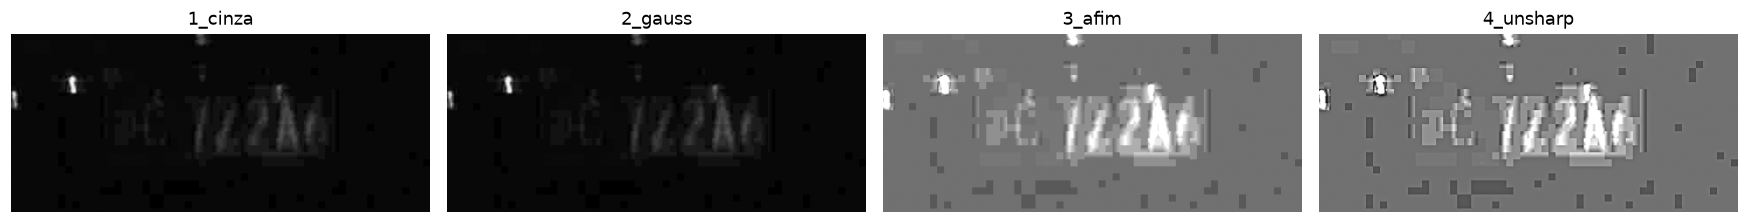

In [20]:
row = df.sort_values("plate_brightness_mean").iloc[3]
img, bbox = load_bgr(row), bbox_of(row)
out, (a, b), stages = pp.run_linear_pipeline(img, pp.GLOBAL_PARAMS, return_stages=True)
print(f"{row['filename'][:45]}...  afim: a = {a:.3f}, b = {b:.1f}")
fig, axes = plt.subplots(1, len(stages), figsize=(4 * len(stages), 3.6))
for ax, (name, st) in zip(axes, stages.items()):
    ax.imshow(crop_with_margin(st, bbox), cmap="gray", vmin=0, vmax=255); ax.set_title(name); ax.axis("off")
fig.tight_layout(); plt.show()

# Parte 3 — Análise dos Resultados

## 3.1 Resultados agregados nas 100 imagens

In [21]:
def summarize(d):
    return {
        "taxa_sucesso_%": 100 * d["success"].mean(),
        "ILL_mediano": d["ill"].median(),
        "ganho_contraste_med": d["contrast_gain"].median(),
        "retencao_nitidez_med": d["sharpness_retention"].median(),
        "saturacao_med_%": 100 * d["clipped_fraction_after"].median(),
        "falha: sem ganho de contraste": int((d["contrast_gain"] <= 1).sum()),
        "falha: perdeu nitidez (<0.9)": int((d["sharpness_retention"] < 0.9).sum()),
        "falha: saturou (>=5%)": int((d["clipped_fraction_after"] >= 0.05).sum()),
        "falha: brilho fora [40,215]": int(((d["brightness_mean_after"] < 40) | (d["brightness_mean_after"] > 215)).sum()),
    }
summary = pd.DataFrame({"A — global": summarize(res_A), "B — adaptativo": summarize(res_B)}).round(2)
summary

,A — global,B — adaptativo
taxa_sucesso_%,61.00,88.00
ILL_mediano,0.64,0.82
ganho_contraste_med,1.56,1.76
retencao_nitidez_med,1.63,1.10
saturacao_med_%,0.16,1.06
falha: sem ganho de contraste,16.00,12.00
falha: perdeu nitidez (<0.9),0.00,0.00
falha: saturou (>=5%),23.00,0.00
"falha: brilho fora [40,215]",6.00,0.00


A — global           B — adaptativo          
                              n sucesso_%              n sucesso_%
baixa_luz                  46.0      71.7           46.0      97.8
estourada                  28.0      32.1           28.0      67.9
baixo_contraste            33.0      84.8           33.0     100.0
desfocada                  46.0      65.2           46.0      95.7
ruidosa                    22.0      45.5           22.0      72.7
placa_pequena              27.0      77.8           27.0      88.9
sem_problema_marcado        3.0      66.7            3.0     100.0

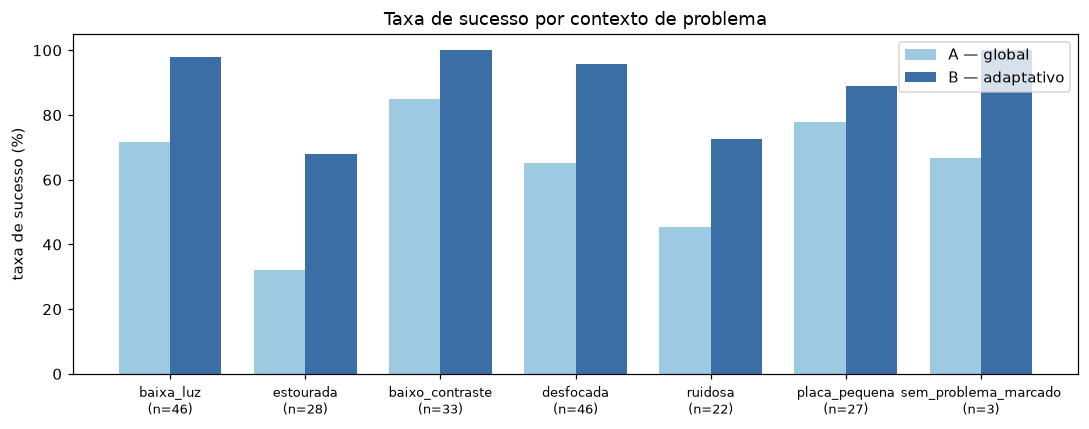

In [22]:
def per_category(d):
    out = {}
    for c in CATS:
        sub = d[d[f"flag_{c}"]]
        out[c] = {"n": len(sub), "sucesso_%": 100 * sub["success"].mean()}
    n_flags = d[[f"flag_{c}" for c in CATS]].sum(axis=1)
    out["sem_problema_marcado"] = {"n": int((n_flags == 0).sum()), "sucesso_%": 100 * d[n_flags == 0]["success"].mean()}
    return pd.DataFrame(out).T

cat_A, cat_B = per_category(res_A), per_category(res_B)
cat_table = pd.concat({"A — global": cat_A, "B — adaptativo": cat_B}, axis=1).round(1)
display(cat_table)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(cat_A)); w = 0.38
ax.bar(x - w / 2, cat_A["sucesso_%"], w, label="A — global", color="#9ecae1")
ax.bar(x + w / 2, cat_B["sucesso_%"], w, label="B — adaptativo", color="#3b6ea5")
ax.set_xticks(x); ax.set_xticklabels([f"{c}\n(n={int(n)})" for c, n in zip(cat_A.index, cat_A['n'])], fontsize=8.5)
ax.set_ylabel("taxa de sucesso (%)"); ax.set_ylim(0, 105); ax.legend(); ax.set_title("Taxa de sucesso por contexto de problema")
fig.tight_layout(); plt.show()

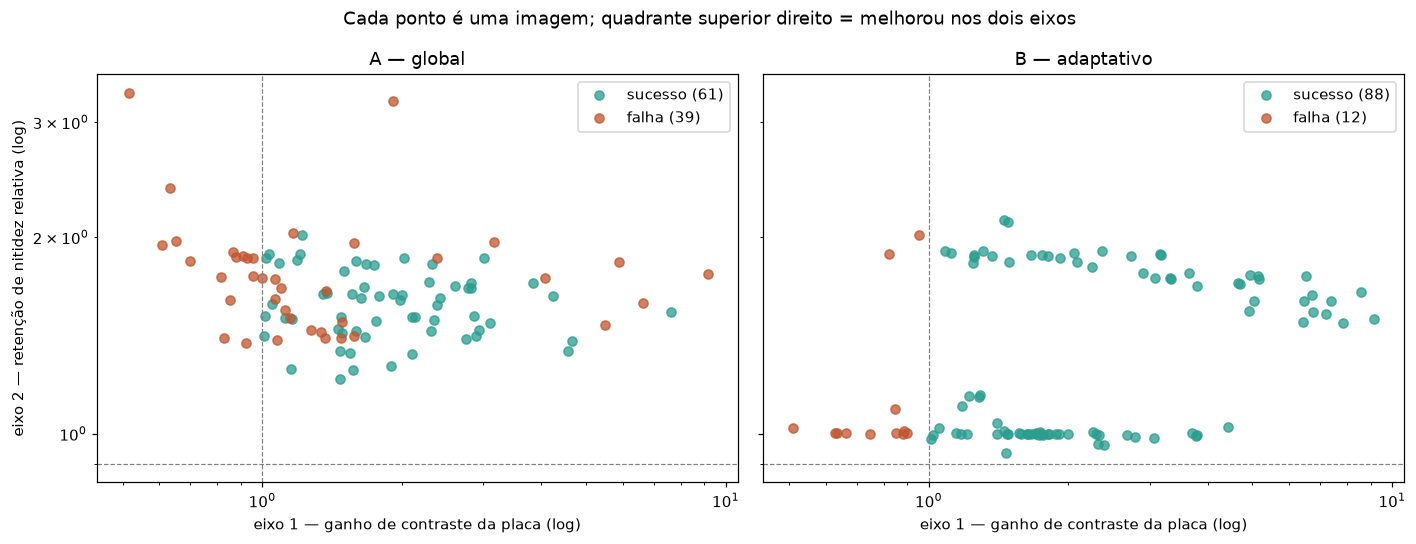

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (name, d) in zip(axes, (("A — global", res_A), ("B — adaptativo", res_B))):
    ok = d["success"]
    ax.scatter(d.loc[ok, "contrast_gain"], d.loc[ok, "sharpness_retention"], c="#2a9d8f", label=f"sucesso ({ok.sum()})", alpha=0.75)
    ax.scatter(d.loc[~ok, "contrast_gain"], d.loc[~ok, "sharpness_retention"], c="#c0562f", label=f"falha ({(~ok).sum()})", alpha=0.75)
    ax.axvline(1, color="gray", ls="--", lw=0.8); ax.axhline(0.9, color="gray", ls="--", lw=0.8)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("eixo 1 — ganho de contraste da placa (log)"); ax.set_title(name); ax.legend()
axes[0].set_ylabel("eixo 2 — retenção de nitidez relativa (log)")
fig.suptitle("Cada ponto é uma imagem; quadrante superior direito = melhorou nos dois eixos"); fig.tight_layout(); plt.show()

## 3.2 Antes / depois — recortes da placa

Mesmas imagens para A e B: três sucessos e três falhas do pipeline global, para ver **o que** a métrica está premiando e punindo.

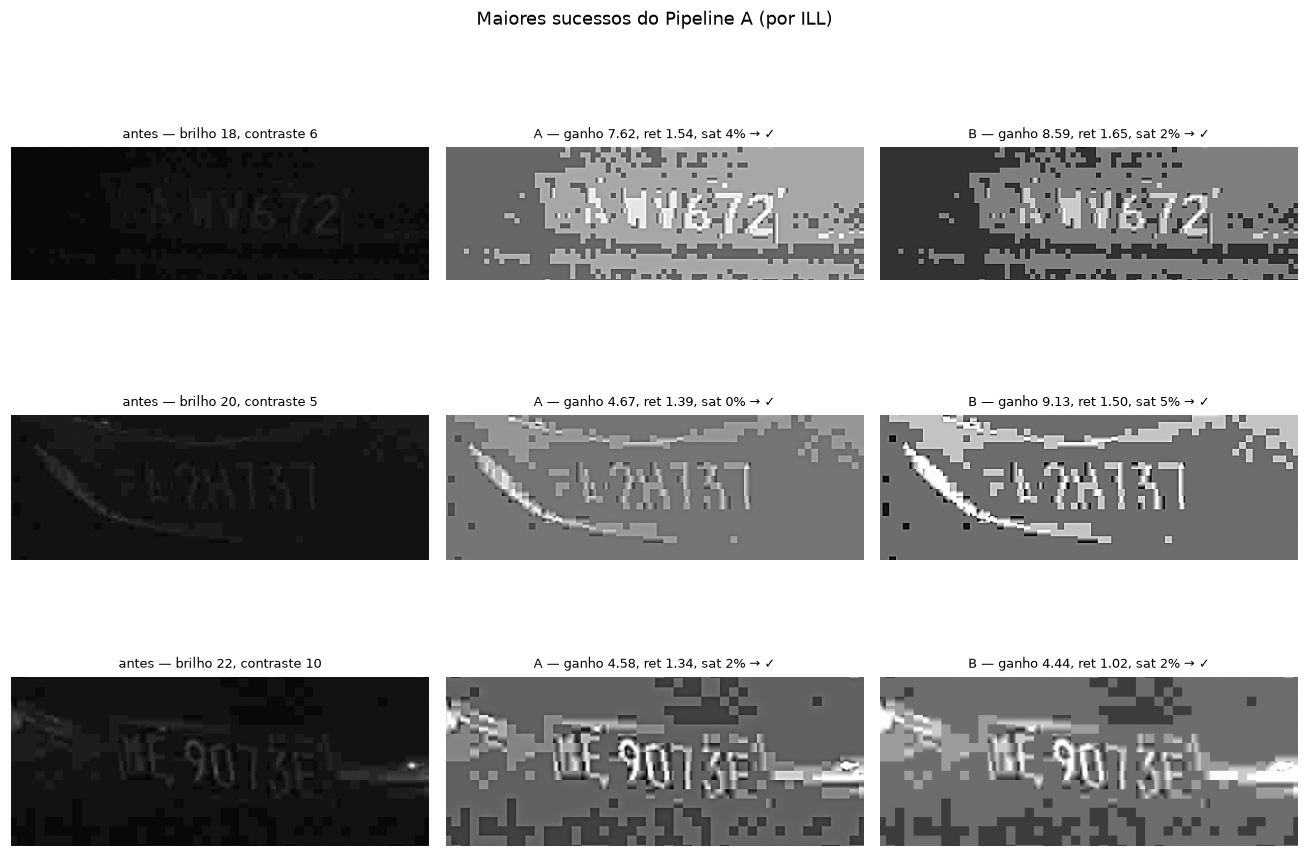

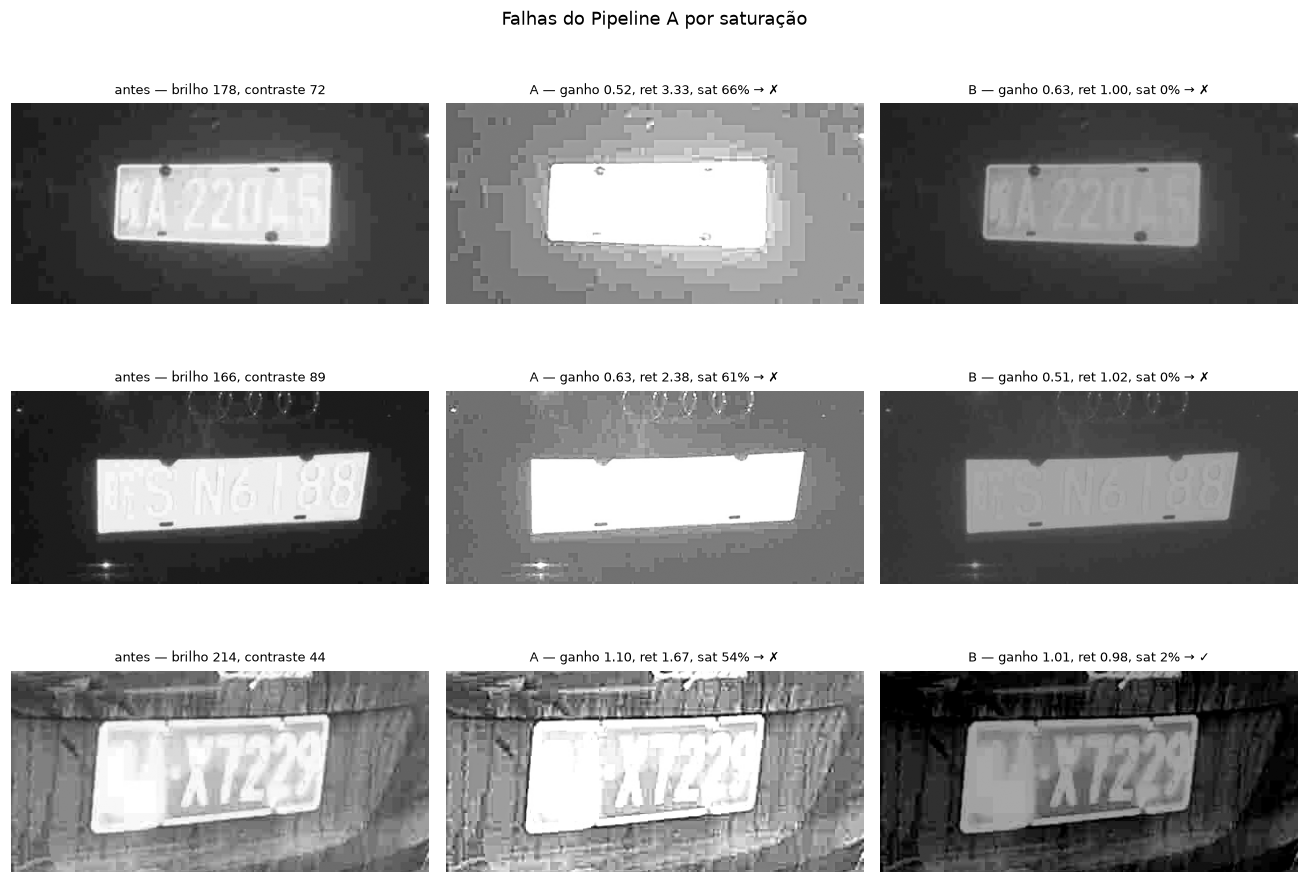

In [24]:
def show_before_after(rows_sel, title):
    fig, axes = plt.subplots(len(rows_sel), 3, figsize=(12, 2.9 * len(rows_sel)))
    for i, (_, rec) in enumerate(rows_sel.iterrows()):
        bbox = pp.parse_ccpd_bbox(Path(rec["filename"]).stem)
        orig = pp.to_gray(cv2.imread(rec["original_path"]))
        outA = cv2.imread(str(OUT_GLOBAL / rec["filename"]), cv2.IMREAD_GRAYSCALE)
        outB = cv2.imread(str(OUT_ADAPTIVE / rec["filename"]), cv2.IMREAD_GRAYSCALE)
        rB = res_B[res_B["filename"] == rec["filename"]].iloc[0]
        for ax, im, lab in zip(axes[i], (orig, outA, outB), (
                f"antes — brilho {rec['brightness_mean_before']:.0f}, contraste {rec['contrast_std_before']:.0f}",
                f"A — ganho {rec['contrast_gain']:.2f}, ret {rec['sharpness_retention']:.2f}, sat {100*rec['clipped_fraction_after']:.0f}% → {'✓' if rec['success'] else '✗'}",
                f"B — ganho {rB['contrast_gain']:.2f}, ret {rB['sharpness_retention']:.2f}, sat {100*rB['clipped_fraction_after']:.0f}% → {'✓' if rB['success'] else '✗'}")):
            ax.imshow(crop_with_margin(im, bbox), cmap="gray", vmin=0, vmax=255); ax.set_title(lab, fontsize=8.5); ax.axis("off")
    fig.suptitle(title); fig.tight_layout(); plt.show()

show_before_after(res_A[res_A["success"]].sort_values("ill", ascending=False).head(3), "Maiores sucessos do Pipeline A (por ILL)")
show_before_after(res_A[~res_A["success"]].sort_values("clipped_fraction_after", ascending=False).head(3), "Falhas do Pipeline A por saturação")

## 3.3 Onde e por que o pipeline global falha

Os modos de falha de A, pelos números da seção 3.1 e pelas imagens acima:

1. **Saturação (o maior grupo de falhas de A).** A afim lê $\mu,\sigma$ da **cena**. Quando a cena é escura mas a placa é clara (placas "estouradas"), $a>1$ é calculado para levantar o fundo — e empurra a placa para 255. É um erro estrutural do pipeline global: a estatística certa para a placa não está na cena.
2. **Sem ganho de contraste.** Em cenas de alto contraste (céu + sombra) com placa de contraste moderado, a afim da cena tem $a<1$ e **comprime** a placa. Mesmo mecanismo, sinal oposto.
3. **Ruidosa.** O único remédio linear (suavizar) troca ruído por nitidez, e a métrica pune essa troca — **nenhum dos dois pipelines trata ruído**. A taxa de sucesso de B nesse contexto vem apenas da normalização de contraste, não de denoising.
4. **Placa pequena.** Filtro linear não cria resolução. A afim ainda ajuda (contraste), mas o teto é baixo.

O Pipeline B resolve (1) e (2) **sem nenhum filtro novo**: apenas lê $\mu,\sigma$ do recorte da placa. As falhas restantes de B têm um único motivo (tabela abaixo): "sem ganho de contraste". Em 11 das 12, o contraste de entrada **já era maior que o alvo** $\sigma=45$ e a afim as *comprime* ($a<1$) — o alvo fixo funciona como teto; a 12ª é uma placa quase preta que já entrava com ~28 % dos pixels saturados em 0 (informação perdida antes do pipeline). A correção natural (nunca reduzir contraste, $a \ge 1$) continua sendo uma transformação afim e fica registrada como próximo passo — não aplicada aqui para não recalibrar depois de ver o resultado.

In [25]:
cols = ["filename", "contrast_gain", "sharpness_retention", "clipped_fraction_after", "brightness_mean_before",
        "brightness_mean_after", "affine_a", "success"]
print("Piores falhas de A por saturacao:")
display(res_A.loc[~res_A["success"], cols].sort_values("clipped_fraction_after", ascending=False).head(5).round(3))

both_fail = (~res_A["success"]) & (~res_B["success"])
print(f"Falham em A e B: {both_fail.sum()} | so A falha: {((~res_A['success']) & res_B['success']).sum()} | so B falha: {(res_A['success'] & ~res_B['success']).sum()}")
print("Flags das imagens que falham nos dois pipelines:")
print(res_B.loc[both_fail, [f"flag_{c}" for c in CATS]].sum().to_dict())
print("Falhas de B por motivo:")
d = res_B[~res_B["success"]]
print({"sem ganho de contraste": int((d["contrast_gain"] <= 1).sum()), "perdeu nitidez": int((d["sharpness_retention"] < 0.9).sum()),
       "saturou": int((d["clipped_fraction_after"] >= 0.05).sum())})
print(f"Contraste de entrada das falhas de B: min {d['contrast_std_before'].min():.1f}, mediana {d['contrast_std_before'].median():.1f} "
      f"(alvo da afim = {pp.ADAPTIVE_BASE.target_std:.0f}); coeficiente a < 1 em {(d['affine_a'] < 1).sum()} de {len(d)}")

Piores falhas de A por saturacao:


,filename,contrast_gain,sharpness_retention,clipped_fraction_after,brightness_mean_before,brightness_mean_after,affine_a,success
67,0351-2_0-221&488_468&607-463&607_221&598_226&4...,0.516,3.330,0.661,177.660,231.116,1.691,False
97,0938-1_3-191&448_624&629-609&629_191&618_206&4...,0.633,2.380,0.606,165.808,210.791,1.141,False
57,0301-2_9-316&472_545&582-532&573_316&582_329&4...,1.100,1.672,0.540,214.368,226.898,1.084,False
25,0168-0_5-210&479_408&550-408&548_217&550_210&4...,1.364,1.399,0.414,195.194,196.678,1.064,False
84,0476-0_0-168&480_520&593-518&593_168&589_170&4...,1.274,1.443,0.389,222.840,232.973,1.137,False


Falham em A e B: 10 | so A falha: 29 | so B falha: 2
Flags das imagens que falham nos dois pipelines:
{'flag_baixa_luz': 1, 'flag_estourada': 8, 'flag_baixo_contraste': 0, 'flag_desfocada': 1, 'flag_ruidosa': 5, 'flag_placa_pequena': 3}
Falhas de B por motivo:
{'sem ganho de contraste': 12, 'perdeu nitidez': 0, 'saturou': 0}
Contraste de entrada das falhas de B: min 42.6, mediana 54.1 (alvo da afim = 45); coeficiente a < 1 em 11 de 12


## 3.4 Conclusão — um pipeline serve a todas?

**Não.** O Pipeline A — o melhor pipeline linear global que a busca em grade encontrou, com parâmetros idênticos para as 100 imagens — cumpre a métrica em cerca de **6 de cada 10 placas** (tabela 3.1), e as falhas não são ruído estatístico: são dois mecanismos previsíveis (saturação de placas claras em cenas escuras; compressão de placas em cenas de alto contraste), ambos consequência de uma única escolha — calcular a normalização a partir da cena e não da placa.

**O que generaliza não é o filtro, é a estatística.** O Pipeline B usa exatamente os mesmos blocos lineares e chega a cerca de **9 de cada 10 placas** em sucesso; a ablação (2.4) mostra que quase todo esse ganho vem de ler $\mu,\sigma$ no recorte da placa, e não da escolha ou do ajuste dos filtros espaciais. Em outras palavras: se o dataset fosse entregue já recortado nas placas (como no exemplo do professor), A e B praticamente coincidiriam — a pergunta "um pipeline serve a todas?" depende mais do enquadramento da entrada do que da cadeia de filtros.

**Restrição de linearidade — o que ela custou.** Três contextos ficam sem solução linear satisfatória: ruído (a única ferramenta linear é suavizar, e isso destrói a estrutura que se quer preservar), placa pequena (nenhum filtro linear cria resolução) e saturação já presente na entrada (informação perdida antes do pipeline). Um pipeline não-linear (CLAHE, mediana, non-local means) atacaria o primeiro e o terceiro; a restrição da prática tornou esse custo visível e mensurável.

**Próximo passo óbvio (não aplicado, para não ajustar depois de medir):** as falhas remanescentes de B são placas que já tinham contraste acima do alvo e foram comprimidas; impedir $a<1$ na afim é uma mudança de um escalar que continua linear.

**Limitações desta análise, para leitura honesta dos números:**
* a métrica não distingue ruído de borda, então é conservadora com denoising e o contexto "ruidosa" (22 imagens) é, na prática, não avaliado;
* o estimador de ruído por wavelet retorna 0 em muitas placas, o que torna frágil o próprio diagnóstico "ruidosa";
* limiares e parâmetros foram calibrados nas mesmas 100 imagens em que são avaliados — não há conjunto de teste separado, então as taxas de sucesso são otimistas;
* não há *ground truth* de OCR: "legibilidade" aqui é um proxy objetivo (contraste + estrutura + saturação), não leitura de caracteres.

# 4. Entregáveis

* `vc_pratica1_grupo1.ipynb` — este notebook, executado.
* `vc_pratica1_grupo1_imagens.zip` — **100 imagens filtradas pelo Pipeline B**, mesmos nomes das originais.
* Diagrama de blocos — seção 2.1. Código dos blocos e pipelines — `preprocessing_pipeline.py`.

O `.zip` é gerado aqui, a partir da pasta escrita na seção 2.5, para que o conteúdo coincida com as saídas deste notebook. As saídas do Pipeline A (`images_processed_global/`) ficam só em disco, para as figuras comparativas.

In [26]:
def make_zip(folder, zip_path):
    names = sorted(p for p in folder.glob("*.jpg"))
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_STORED) as zf:
        for p in names:
            zf.write(p, arcname=p.name)
    with zipfile.ZipFile(zip_path) as zf:
        listed = sorted(zf.namelist())
    assert len(listed) == 100 and listed == [p.name for p in names]
    print(f"{zip_path}: {len(listed)} imagens, {zip_path.stat().st_size / 1e6:.1f} MB")

make_zip(OUT_ADAPTIVE, Path("vc_pratica1_grupo1_imagens.zip"))

vc_pratica1_grupo1_imagens.zip: 100 imagens, 7.4 MB
